# Sugarcane Production Project - Overview

## Data Cleaning

### 1. Data Cleaning Process

In [9]:
import pandas as pd

# Load the dataset
data = pd.read_csv('List of Countries by Sugarcane Production.csv')

data.head()

,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768.678.382,"3.668,531",10.226.205,"75.167,5"
1,1,India,Asia,348.448.000,260721,4.950.000,"70.393,5"
2,2,China,Asia,123.059.739,88287,1.675.215,"73.459,1"
3,3,Thailand,Asia,87.468.496,"1.264,303",1.336.575,"65.442,2"
4,4,Pakistan,Asia,65.450.704,324219,1.130.820,57.879


#### Remove Unwanted Characters

In [10]:
# Remove Unwanted characters (.) and (,) from the column names Production and Acreage
data['Production (Tons)'] = data['Production (Tons)'].astype(str).str.replace('.', '', regex=False).str.replace(',', '', regex=False).astype(float)
data['Acreage (Hectare)'] = data['Acreage (Hectare)'].astype(str).str.replace('.', '', regex=False).str.replace(',', '', regex=False).astype(float)

# Removing Commas(,) with periods(.) in the Production per Persion columns
# data['Production per Person (Kg)'] = data['Production per Person (Kg)'].astype(str).str.replace(',', '.', regex=False).astype(float)

# Convert Column to numeric Data Type
data['Production (Tons)'] = pd.to_numeric(data['Production (Tons)'], errors='coerce')
data['Acreage (Hectare)'] = pd.to_numeric(data['Acreage (Hectare)'], errors='coerce')
data['Production per Person (Kg)'] = pd.to_numeric(data['Production per Person (Kg)'], errors='coerce')

#### Remove Unwanted Columns

In [11]:
data.drop(columns=['Unnamed: 0'], inplace=True)

#### Rename Columns for Consistency

In [12]:
data.rename(columns={'Production (Tons)': 'Production_Tons'})

,Country,Continent,Production_Tons,Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,Brazil,South America,768678382.0,NaN,10226205.0,"75.167,5"
1,India,Asia,348448000.0,260721.0,4950000.0,"70.393,5"
2,China,Asia,123059739.0,88287.0,1675215.0,"73.459,1"
3,Thailand,Asia,87468496.0,NaN,1336575.0,"65.442,2"
4,Pakistan,Asia,65450704.0,324219.0,1130820.0,57.879
...,...,...,...,...,...,...
98,Lebanon,Asia,97.0,16.0,3.0,"28.386,4"
99,Djibouti,Africa,53.0,51.0,NaN,NaN
100,Singapore,Asia,50.0,9.0,2.0,25
101,Samoa,Oceania,12.0,6.0,1.0,"11.949,8"


### 2. Checking Missing Values

#### Missing Values Output:

In [13]:
data.isna().sum()

Country                        0
Continent                      0
Production (Tons)              0
Production per Person (Kg)    13
Acreage (Hectare)              1
Yield (Kg / Hectare)           1
dtype: int64

#### Handling Missing Values:

In [14]:
data = data.dropna(subset=['Acreage (Hectare)', 'Yield (Kg / Hectare)'])
data = data.reset_index(drop=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Country                     102 non-null    object 
 1   Continent                   102 non-null    object 
 2   Production (Tons)           102 non-null    float64
 3   Production per Person (Kg)  89 non-null     float64
 4   Acreage (Hectare)           102 non-null    float64
 5   Yield (Kg / Hectare)        102 non-null    object 
dtypes: float64(3), object(3)
memory usage: 4.9+ KB


### 3. Data Conversion

In [15]:
data['Yield (Kg / Hectare)'] = data['Yield (Kg / Hectare)'].astype(str).str.replace('.', '', regex=False).str.replace(',', '', regex=False).astype(float)

## Univariate Analysis

#### 1. How Many Countries Produce Sugarcane from Each Continent?

In [16]:
data.groupby('Continent')['Country'].nunique().reset_index().sort_values(by='Country', ascending=False)

,Continent,Country
0,Africa,38
1,Asia,25
3,North America,22
5,South America,11
4,Oceania,4
2,Europe,2


### 2. Distribution of Key Variables

Productoin in Tons

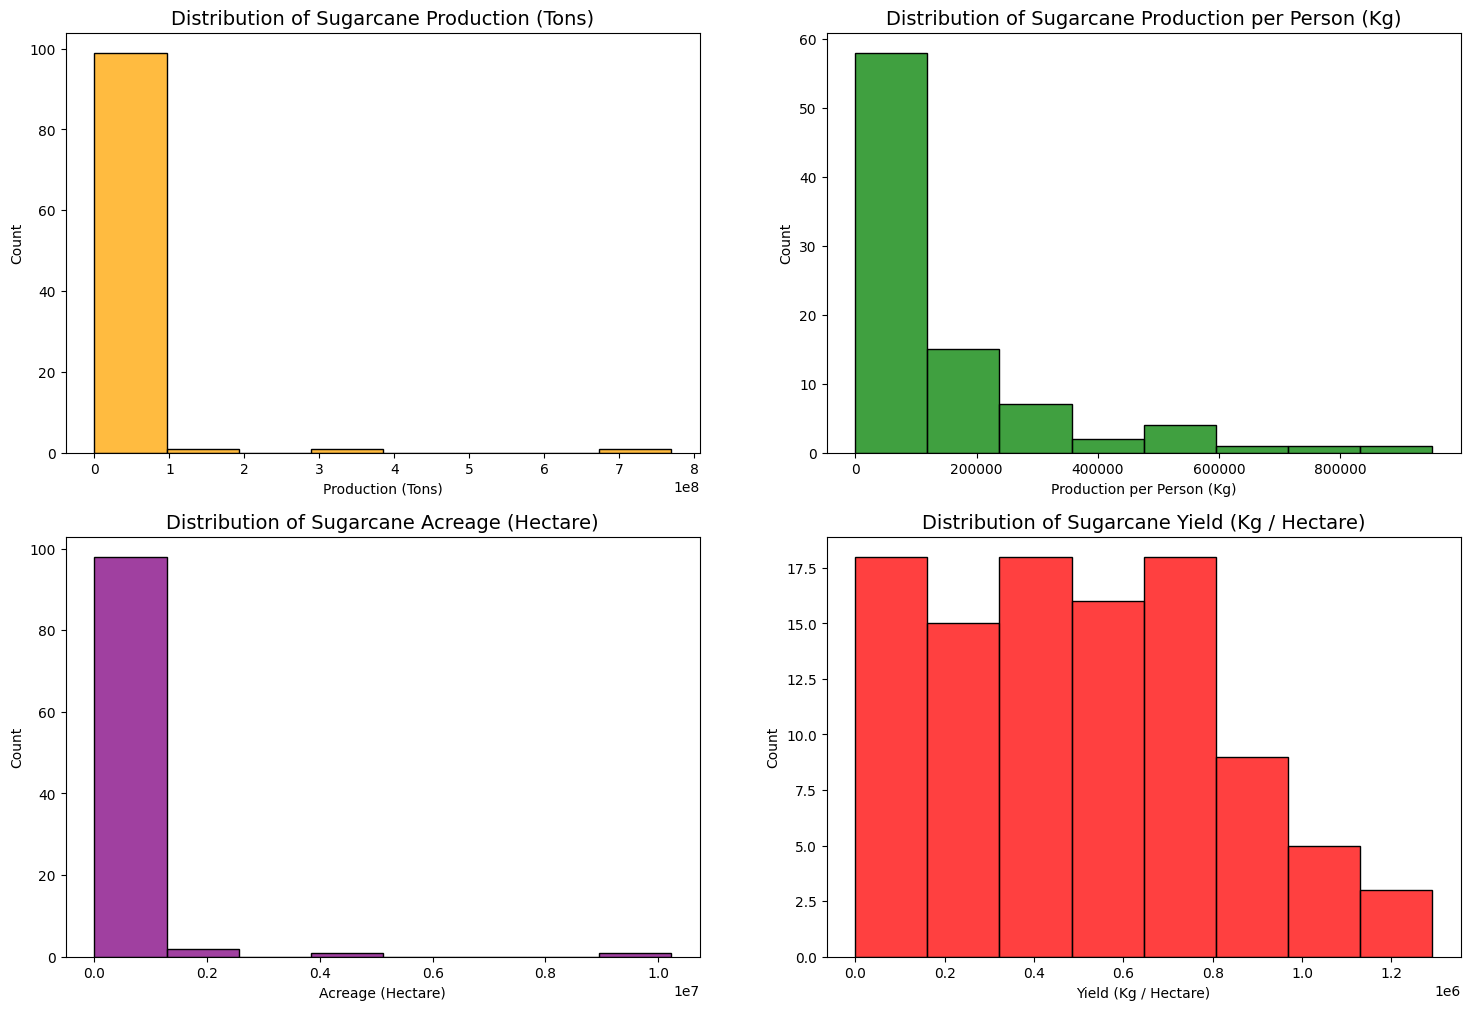

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# ************************* This is the traditional way to plot histogram using matplotlib library **************************
# # Step 1: Plot histogram
# plt.figure(figsize=(10, 4))
# plt.hist(data['Production (Tons)'], bins=8, edgecolor='black', color='skyblue')

# # Step 2: Add labels and title
# plt.title('Distribution of Sugarcane Production (Tons)', fontsize=14)
# plt.xlabel('Production (Tons)', fontsize=12)
# plt.ylabel('Number of Countries', fontsize=12)


# * ************************** We can also use seaborn library to plot histogram **************************
# fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plt.figure(figsize=(18, 12))

plt.subplot(2, 2, 1)
sns.histplot(data['Production (Tons)'], bins=8, kde=False, color='orange')
plt.title('Distribution of Sugarcane Production (Tons)', fontsize=14)

plt.subplot(2, 2, 2)
sns.histplot(data['Production per Person (Kg)'], bins=8, kde=False, color='green')
plt.title('Distribution of Sugarcane Production per Person (Kg)', fontsize=14)

plt.subplot(2, 2, 3)
sns.histplot(data['Acreage (Hectare)'], bins=8, kde=False, color='purple')
plt.title('Distribution of Sugarcane Acreage (Hectare)', fontsize=14)

plt.subplot(2, 2, 4)
sns.histplot(data['Yield (Kg / Hectare)'], bins=8, kde=False, color='red')
plt.title('Distribution of Sugarcane Yield (Kg / Hectare)', fontsize=14)

# Step 3: Display plot
plt.show()


Using sns.distplot(), we visualize the distribution of these variables, helping us identify skewness, normality, and outliers.

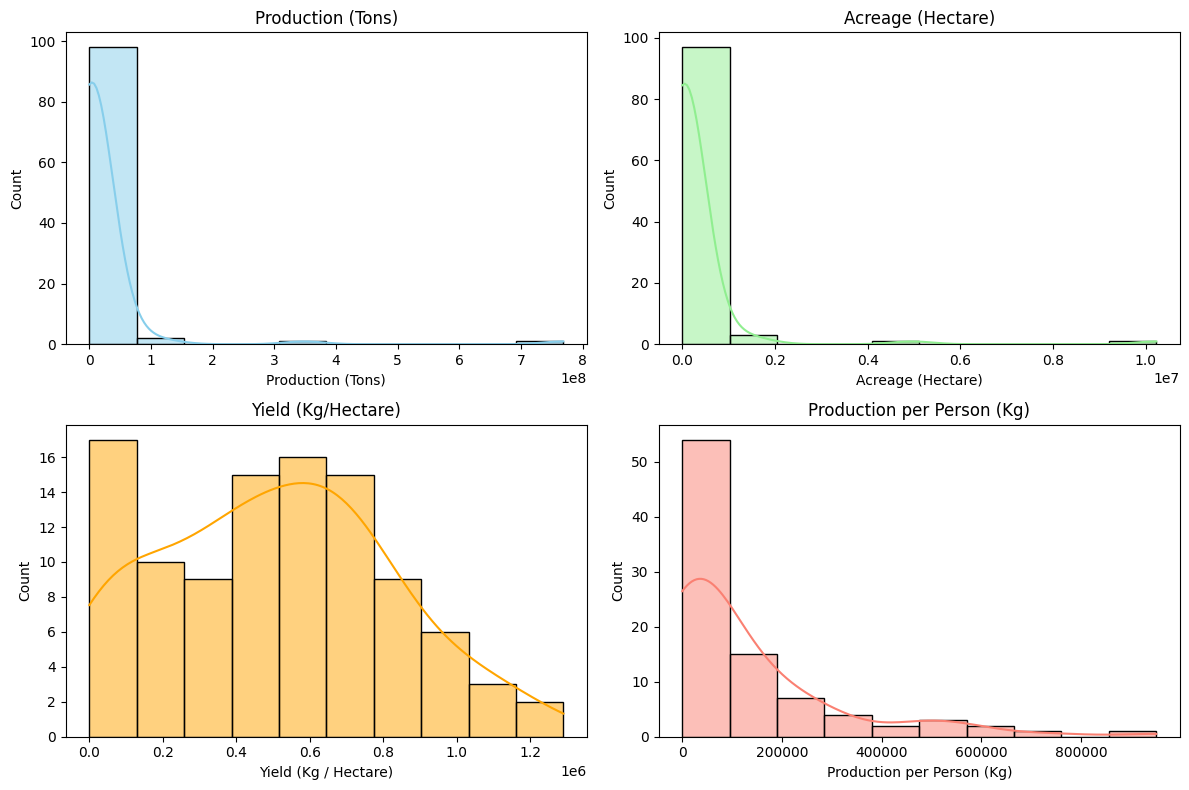

In [ ]:

# todo : Using seaborn distplot to plot the distribution of Production, Acreage, Yield, and Production per Person
# # Set figure size
# plt.figure(figsize=(12, 8))

# # Plot distributions
# plt.subplot(2, 2, 1)
# sns.distplot(data['Production (Tons)'], bins=10, color='skyblue')
# plt.title('Distribution of Production (Tons)')

# plt.subplot(2, 2, 2)
# sns.distplot(data['Acreage (Hectare)'], bins=10, color='lightgreen')
# plt.title('Distribution of Acreage (Hectare)')

# plt.subplot(2, 2, 3)
# sns.distplot(data['Yield (Kg / Hectare)'], bins=10, color='orange')
# plt.title('Distribution of Yield (Kg/Hectare)')

# plt.subplot(2, 2, 4)
# sns.distplot(data['Production per Person (Kg)'], bins=10, color='salmon')
# plt.title('Distribution of Production per Person (Kg)')

# plt.tight_layout()
# plt.show()


# todo : Using seaborn histplot to plot the distribution of Production, Acreage, Yield, and Production per Person

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.histplot(data['Production (Tons)'], bins=10, kde=True, color='skyblue')
plt.title('Production (Tons)')

plt.subplot(2, 2, 2)
sns.histplot(data['Acreage (Hectare)'], bins=10, kde=True, color='lightgreen')
plt.title('Acreage (Hectare)')

plt.subplot(2, 2, 3)
sns.histplot(data['Yield (Kg / Hectare)'], bins=10, kde=True, color='orange')
plt.title('Yield (Kg/Hectare)')

plt.subplot(2, 2, 4)
sns.histplot(data['Production per Person (Kg)'], bins=10, kde=True, color='salmon')
plt.title('Production per Person (Kg)')

plt.tight_layout()
plt.show()


### 3. Outlier Detection with Boxplots

<Axes: xlabel='Yield (Kg / Hectare)'>

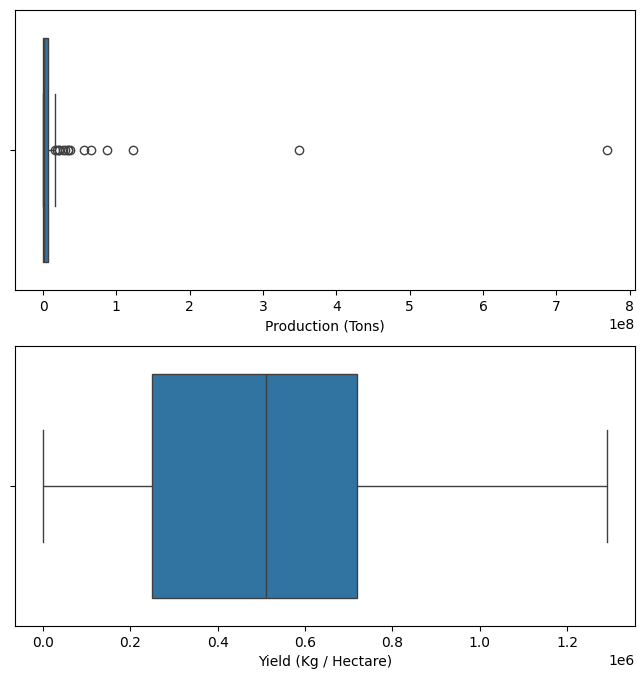

In [83]:
plt.figure(figsize=(8, 8))

plt.subplot(2,1,1)
sns.boxplot(x=data['Production (Tons)'])

plt.subplot(2,1,2)
sns.boxplot(x=data['Yield (Kg / Hectare)'])

### 4. Violin Plot for Production (Tons)

<Axes: xlabel='Production (Tons)'>

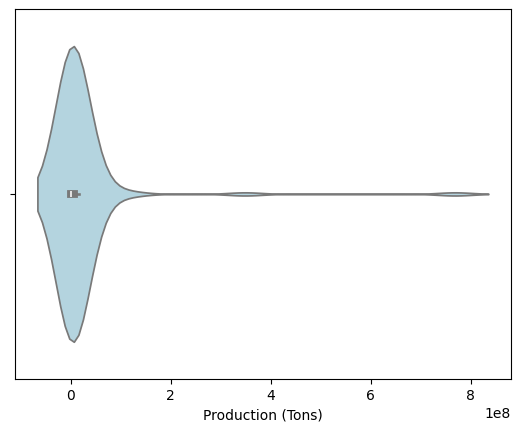

In [84]:
sns.violinplot(x=data['Production (Tons)'], color='lightblue')

## Bivariate Analysis

#### 1. Which Country Has the Highest Acreage (Land)?

C:\Users\Rohit Kumar\AppData\Local\Temp\ipykernel_1848\2475605530.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Country', y='Acreage (Hectare)', data=data.sort_values(by='Acreage (Hectare)', ascending=False).head(10), palette='viridis')


<Axes: xlabel='Country', ylabel='Acreage (Hectare)'>

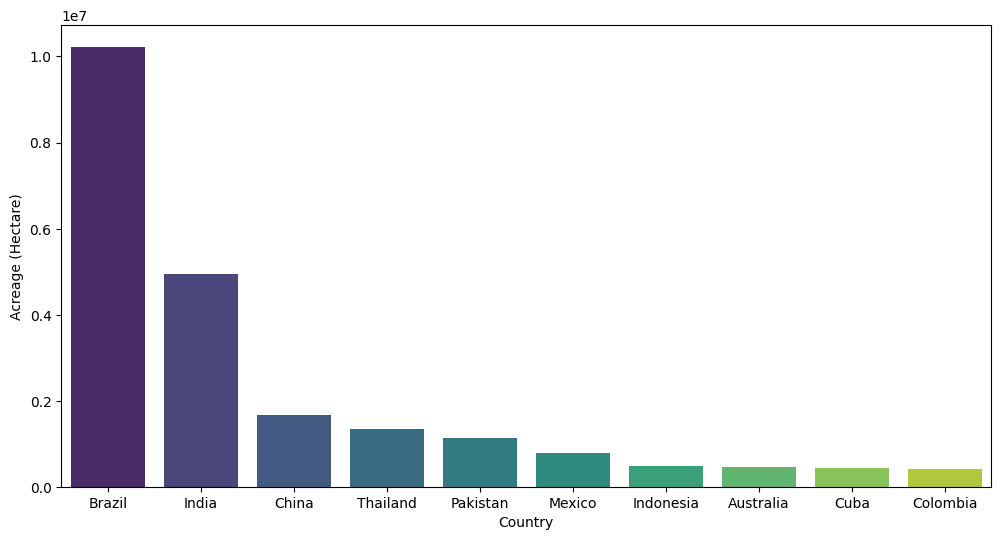

In [86]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Country', y='Acreage (Hectare)', data=data.sort_values(by='Acreage (Hectare)', ascending=False).head(10), palette='viridis')

#### 2. Which Country Has the Highest Yield per Hectare?

C:\Users\Rohit Kumar\AppData\Local\Temp\ipykernel_1848\3208661631.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Country', y='Yield (Kg / Hectare)', data=data.sort_values(by='Yield (Kg / Hectare)', ascending=False).head(10), palette='magma')


<Axes: xlabel='Country', ylabel='Yield (Kg / Hectare)'>

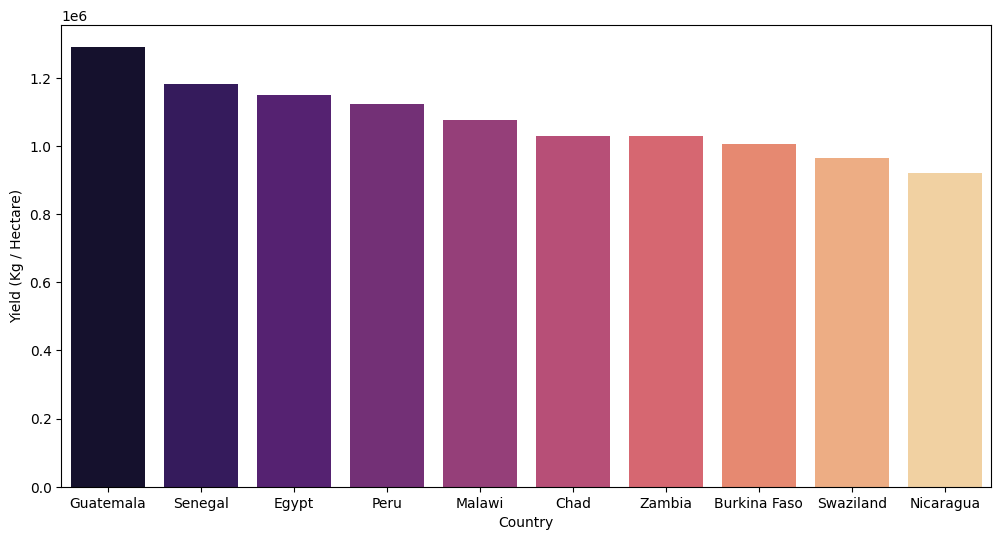

In [87]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Country', y='Yield (Kg / Hectare)', data=data.sort_values(by='Yield (Kg / Hectare)', ascending=False).head(10), palette='magma')

#### 3. Which Country Has the Highest Production per Person?

C:\Users\Rohit Kumar\AppData\Local\Temp\ipykernel_1848\3208661631.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Country', y='Yield (Kg / Hectare)', data=data.sort_values(by='Yield (Kg / Hectare)', ascending=False).head(10), palette='magma')


<Axes: xlabel='Country', ylabel='Yield (Kg / Hectare)'>

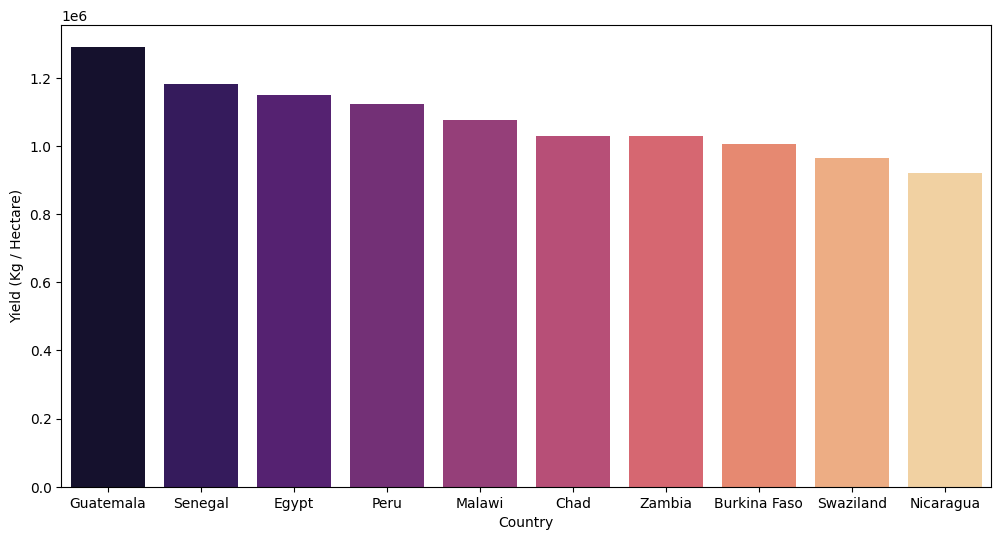

In [89]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Country', y='Yield (Kg / Hectare)', data=data.sort_values(by='Yield (Kg / Hectare)', ascending=False).head(10), palette='magma')

### 4. Correlation Analysis

##### Production (Tons) and Acreage (Hectare)

In [92]:
corrval = data['Production (Tons)'].corr(data['Acreage (Hectare)'])
corrval

np.float64(0.9975501610516623)

#### Production (Tons) and Yield (Kg/Hectare)

In [93]:
corrval = data['Production (Tons)'].corr(data['Yield (Kg / Hectare)'])
corrval

np.float64(0.12112478659999346)

#### 5. Do Countries with the Highest Land Produce More Sugarcane?

<Axes: xlabel='Acreage (Hectare)', ylabel='Production (Tons)'>

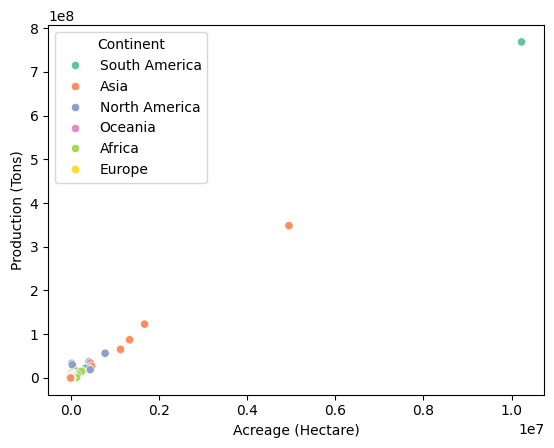

In [98]:
sns.scatterplot(x='Acreage (Hectare)', y='Production (Tons)', data=data, hue='Continent', palette='Set2')

#### 6. Do Countries Yield More Sugarcane per Hectare Produce More Sugarcane in Total?

<Axes: xlabel='Yield (Kg / Hectare)', ylabel='Production (Tons)'>

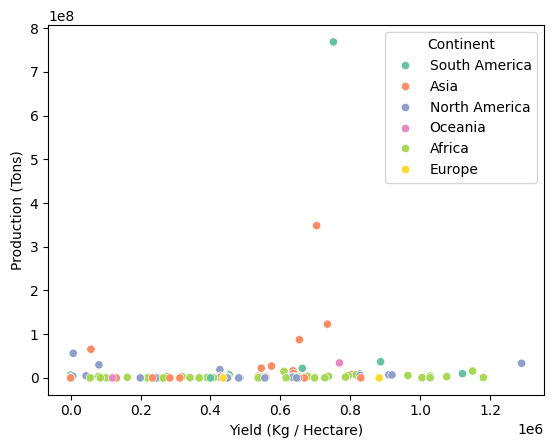

In [99]:
sns.scatterplot(x='Yield (Kg / Hectare)', y='Production (Tons)', data=data, hue='Continent', palette='Set2')

## Continental Analysis

### 1. Analyzing Sugarcane Production by Continent

In [106]:
# Step 1: Group data by continent and sum numeric values
continent_summary = (
    data.groupby('Continent')[['Production (Tons)', 'Acreage (Hectare)', 'Yield (Kg / Hectare)']]
      .sum()
      .sort_values(by='Production (Tons)', ascending=False)
)

# Step 2: Display summary table
print("Total Production by Continent:\n")
continent_summary

Total Production by Continent:



,Production (Tons),Acreage (Hectare),Yield (Kg / Hectare)
Continent,,,
South America,865588126.0,11369236.0,6766896.0
Asia,721930425.0,10608319.0,11197308.0
North America,173995947.0,1581983.0,9581162.0
Africa,89681472.0,1439089.0,20700454.0
Oceania,36177574.0,490909.0,1624191.0
Europe,5823.0,71.0,1318709.0


#### 2. Does the Number of Countries in a Continent Affect Sugarcane Production?

In [107]:
continent_stats = (
    data.groupby('Continent')
      .agg({
          'Country': 'nunique',          # number of unique countries
          'Production (Tons)': 'sum'     # total production
      })
      .rename(columns={'Country': 'Number of Countries', 'Production (Tons)': 'Total Production'})
      .reset_index()
)

continent_stats

,Continent,Number of Countries,Total Production
0,Africa,38,89681472.0
1,Asia,25,721930425.0
2,Europe,2,5823.0
3,North America,22,173995947.0
4,Oceania,4,36177574.0
5,South America,11,865588126.0
